In [14]:
# Import pandas to read and work with stock price CSV files.
import pandas as pd

# Import matplotlib to draw stock price graphs.
import matplotlib.pyplot as plt

# Import NumPy for numerical operations and array reshaping.
import numpy as np

### Loading the dataset

In [15]:
# Read the Google stock price training data from the CSV file.
train_df = pd.read_csv('Google_Stock_Price_Train.csv')

# Display column names, data types, and non-null counts for the training data.
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   object 
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   object 
 5   Volume  1258 non-null   object 
dtypes: float64(3), object(3)
memory usage: 59.1+ KB


In [16]:
# Read the Google stock price testing data from the CSV file.
test_df = pd.read_csv('Google_Stock_Price_Test.csv')

# Display column names, data types, and non-null counts for the testing data.
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    20 non-null     object 
 1   Open    20 non-null     float64
 2   High    20 non-null     float64
 3   Low     20 non-null     float64
 4   Close   20 non-null     float64
 5   Volume  20 non-null     object 
dtypes: float64(4), object(2)
memory usage: 1.1+ KB


#### Choosing column 'open' for predicition

In [17]:
# Select only the Open price column for training.
# The model will learn to predict future opening stock prices.
train = train_df.loc[:,["Open"]].values

# Display the shape to check how many training records are available.
train.shape

(1258, 1)

### Feature Scaling

In [18]:
# Import MinMaxScaler to scale stock prices between 0 and 1.
# Scaling helps the RNN train more smoothly.
from sklearn.preprocessing import MinMaxScaler

# Create the scaler object.
scaler = MinMaxScaler()

In [19]:
# Fit the scaler on training prices and transform them to the 0-1 range.
train_scaled = scaler.fit_transform(train)

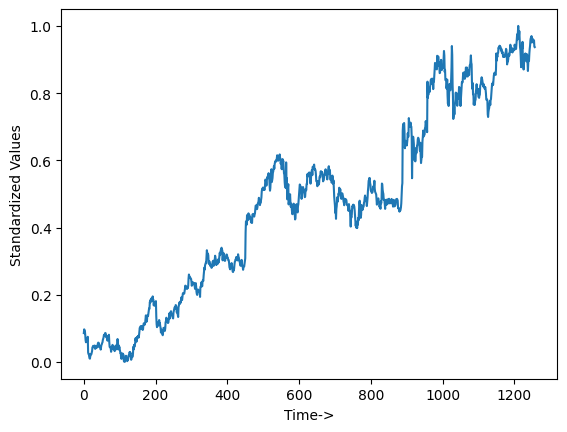

In [20]:
# Plot the scaled training stock prices.
# This helps visualize how prices change over time after scaling.
plt.plot(train_scaled)
plt.ylabel("Standardized Values")
plt.xlabel("Time->")
plt.show()

### Create data structure to train model  
Taking reference of past 60 days to predict future stock price  
x_train will have data of 60 days prior to current date and y_train will have price on current date

In [21]:
# Create empty lists to store training input sequences and target values.
x_train = []
y_train = []

# Use the previous 60 days of prices to predict the next day's price.
time = 60

# Build training samples from the scaled stock price data.
for i in range(60,train_scaled.shape[0]):
    x_train.append(train_scaled[i-60:i,0])
    y_train.append(train_scaled[i,0])

# Convert the lists into NumPy arrays for model training.
x_train = np.array(x_train)
y_train = np.array(y_train)

In [22]:
# Display the shapes of input sequences and target values.
# x_train contains 60-day windows, and y_train contains the next price.
x_train.shape,y_train.shape

((1198, 60), (1198,))

In [23]:
# Reshape x_train into 3D format required by RNN layers.
# Shape format is: samples, time steps, features.
x_train = np.reshape(x_train,newshape=(x_train.shape[0],x_train.shape[1],1))

# Display the new shape after reshaping.
x_train.shape

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30292\3502120353.py:1: DeprecationWarning: `newshape` keyword argument is deprecated, use `shape=...` or pass shape positionally instead. (deprecated in NumPy 2.1)
  x_train = np.reshape(x_train,newshape=(x_train.shape[0],x_train.shape[1],1))


(1198, 60, 1)

### Build model

In [24]:
# Import Sequential to build the neural network layer by layer.
from keras.models import Sequential

# Import Dense for the output layer, SimpleRNN for time-series learning,
# and Dropout to reduce overfitting.
from keras.layers import Dense, SimpleRNN,Dropout

In [25]:
# Create an empty Sequential RNN model.
model = Sequential()

# Add the first RNN layer with 50 units.
# return_sequences=True passes the full sequence to the next RNN layer.
model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True, input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))

# Add the second RNN layer to learn more time-based patterns.
model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True))
model.add(Dropout(0.2))

# Add the third RNN layer for deeper sequence learning.
model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True))
model.add(Dropout(0.2))

# Add the final RNN layer.
# return_sequences is not needed here because the next layer is Dense.
model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))

# Add one output neuron to predict one stock price value.
model.add(Dense(units=1))

# Compile the model using Adam optimizer and mean squared error loss.
model.compile(optimizer='adam',loss='mse')

# Print the model structure and number of trainable parameters.
model.summary()

C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 60, 50)              │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 60, 50)              │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 60, 50)              │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,801 (69.54 KB)

 Trainable params: 17,801 (69.54 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Train the RNN model using the prepared 60-day sequences.
# epochs=100 means the model sees the training data 100 times.
# batch_size=30 means 30 samples are processed before each weight update.
# validation_split=0.05 keeps 5% of training data for validation.
model.fit(x_train,y_train,epochs=100,batch_size=30,validation_split=0.05)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.3831 - val_loss: 0.0206
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.2505 - val_loss: 0.0189
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.1972 - val_loss: 9.0795e-04
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.1354 - val_loss: 6.0899e-04
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0902 - val_loss: 0.0213
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0834 - val_loss: 0.0085
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0630 - val_loss: 0.0072
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0540 - val_loss: 0.0098
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0506 - val_loss: 0.0011
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0402 - val_loss: 5.7592e-04
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0365 - val_loss: 9.9672e-04
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━

### Prepare test dataset

In [27]:
# Combine training and testing Open prices into one continuous series.
# This is needed because each test prediction uses the previous 60 days of prices.
data = pd.concat((train_df['Open'],test_df['Open']),axis=0)

In [28]:
# Select the last 60 training prices plus all test prices.
# These values are used to create the test input sequences.
test_input = data.iloc[len(data) - len(test_df) - time : ].values

# Display the shape of the selected test input data.
test_input.shape

(80,)

In [29]:
# Reshape test input into a 2D array so the scaler can transform it.
test_input = test_input.reshape(-1,1)

# Display the shape after reshaping.
test_input.shape

(80, 1)

In [30]:
# Scale the test input using the same scaler fitted on the training data.
test_scaled = scaler.transform(test_input)

#### Create test data set

In [31]:
# Create empty list to store test input sequences.
x_test = []

# Build 60-day test sequences for prediction.
for i in range(time,test_scaled.shape[0]):
    x_test.append(test_scaled[i - time: i,0 ])

# Convert test sequences into a NumPy array.
x_test = np.array(x_test)

# Display the shape of the test sequence data.
x_test.shape

(20, 60)

In [32]:
# Reshape x_test into 3D format required by the RNN.
# Shape format is: samples, time steps, features.
x_test = np.reshape(x_test,newshape=(x_test.shape[0],x_test.shape[1],1))

# Display the new shape after reshaping.
x_test.shape

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30292\2200062050.py:1: DeprecationWarning: `newshape` keyword argument is deprecated, use `shape=...` or pass shape positionally instead. (deprecated in NumPy 2.1)
  x_test = np.reshape(x_test,newshape=(x_test.shape[0],x_test.shape[1],1))


(20, 60, 1)

In [33]:
# Store the real Open prices from the test dataset.
# These values will be compared with the model predictions.
y_test = test_df.loc[:,"Open"].values

### Model Prediction

In [34]:
# Use the trained RNN model to predict scaled stock prices for the test sequences.
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step


In [35]:
# Convert predicted prices back from scaled values to original price values.
y_pred = scaler.inverse_transform(y_pred)

In [36]:
# Evaluate the model on the test input and real test prices.
# This returns the model loss on the test data.
output = model.evaluate(x=x_test,y=y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step - loss: 650710.5000


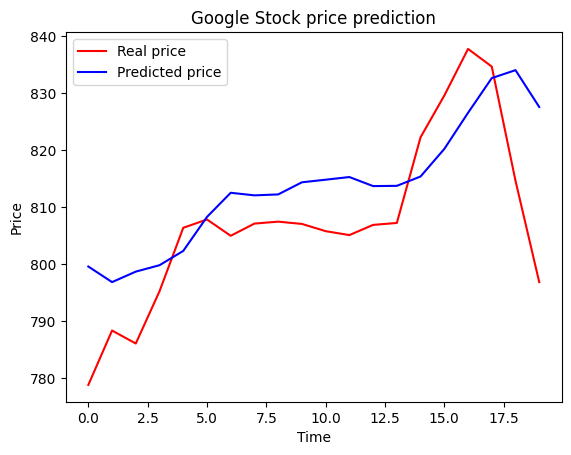

In [37]:
# Plot the real stock prices and predicted stock prices together.
# This makes it easy to visually compare model predictions with actual prices.
plt.plot(y_test, color = 'red', label = 'Real price')
plt.plot(y_pred, color = 'blue', label = 'Predicted price')

plt.title('Google Stock price prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
# This cell is intentionally left blank.